# 2 Integrator Techniques are found in this File:


### 1st Integrator Algorithm

1. **Initialize with the initial condition**

   Sample $(n_x)$ points at $(t=0)$:

   $$
   (x_i,0,u(x_i,0))
   $$

   These points form the initial dataset of known values.

2. **Advance in time strips**

   The time domain is divided into strips $(t_k = k\Delta t)$.  
   The algorithm processes one strip at a time.

3. **Enforce boundary conditions**

   At every strip we insert boundary points    $(0,t_k,0), \quad (1,t_k,0)$

   which enforce the Dirichlet boundary condition, to be equal to 0.

4. **Generate candidate interior points**

   For each strip we sample interior points $x^* $ (slightly randomized).

5. **Find neighbours**

   For each candidate $(x^*,t_k)$, search previously computed points in a space–time expanding box and select the closest $(n)$ neighbours.


6. **Reconstruct the solution**

   The new value is computed as

   $$
   u(x^*,t_k) = \sum_i w_i u_i
   $$

   and the point is added to the dataset.

8. **Repeat**

   Continue for all time strips until \(t=T\).

The result is a **space–time cloud of solution points reconstructed from local stencils**, similar to a generalized finite difference method.

In [10]:
import numpy as np

# ─────────────────────────────────────────────
# Parameters
# ─────────────────────────────────────────────
alpha    = 0.05
c        = 0.5           # advection speed
T        = 0.2
nx_sc    = 20          # points per strip
n_exact  = 5       # neighbours to use
box_x0   = 0.15        # initial box half-width in x
box_t0   = 0.01        # initial box look-back in t
box_xmax = 0.5
box_tmax = T
box_grow = 1.5
cond_max = 1e8

dx_ref = 1.0 / (nx_sc - 1)
dt_sc  = 0.002         # choose directly

t_strips = np.arange(0, T + dt_sc, dt_sc)

print(f"dx_ref = {dx_ref:.5f}, dt_sc = {dt_sc:.5f}, strips = {len(t_strips)-1}")
# ─────────────────────────────────────────────
# True solution and FD reference
# ─────────────────────────────────────────────
def u_true(x, t):
    # Exact solution of u_t + c*u_x = alpha*u_xx, IC sin(pi*x), Dirichlet BCs
    # via transformation u = exp(k*x - k^2*alpha*t) * v, k = c/(2*alpha)
    # v solves pure diffusion with IC exp(-k*x)*sin(pi*x)
    k = c / (2.0 * alpha)
    def f(p):
        if p == 0:
            return (1.0 - np.exp(-k)) / k if k > 1e-10 else 1.0
        return k * (1.0 - (-1)**p * np.exp(-k)) / (k**2 + (p * np.pi)**2)
    x_arr = np.asarray(x, dtype=float)
    v = np.zeros_like(x_arr)
    for n in range(1, 31):
        v += (f(n-1) - f(n+1)) * np.exp(-alpha*(n*np.pi)**2*t) * np.sin(n*np.pi*x_arr)
    result = np.exp(k*x_arr - k**2*alpha*t) * v
    return float(result) if np.ndim(x) == 0 else result

def generate_fd_reference(nx=200, dt=1e-4):
    x = np.linspace(0, 1, nx)
    dx = x[1] - x[0]

    lam = alpha * dt / dx**2   # computed internally
    if lam > 0.3:
        print(f"Warning: scheme may be unstable (λ = {lam:.3f})")

    nt = int(T / dt) + 1

    U = np.zeros((nt, nx))
    U[0] = u_true(x, 0)
    for k in range(nt-1):

        # interior (4th order diffusion + 2nd order advection)
        U[k+1,2:-2] = (
            U[k,2:-2] + lam/12 * (-U[k,4:]+ 16*U[k,3:-1] - 30*U[k,2:-2] + 16*U[k,1:-3] - U[k,:-4] )
            - c*dt/(2*dx) * (U[k,3:-1] - U[k,1:-3])
        )

        # near boundaries (2nd order)
        U[k+1,1] = U[k,1] + lam*(U[k,2] - 2*U[k,1] + U[k,0]) - c*dt/(2*dx)*(U[k,2] - U[k,0])
        U[k+1,-2] = U[k,-2] + lam*(U[k,-1] - 2*U[k,-2] + U[k,-3]) - c*dt/(2*dx)*(U[k,-1] - U[k,-3])

        # Dirichlet BCs
        U[k+1,0] = 0
        U[k+1,-1] = 0
    return x, np.arange(nt) * dt, U
print("Generating FD reference...")
x_fd, t_fd, U_fd = generate_fd_reference()

def fd_interp(xq, tq):
    ix = np.clip(np.searchsorted(x_fd, xq) - 1, 0, len(x_fd) - 2)
    it = np.clip(np.searchsorted(t_fd, tq) - 1, 0, len(t_fd) - 2)
    tx = (xq - x_fd[ix]) / (x_fd[ix + 1] - x_fd[ix])
    tt = (tq - t_fd[it]) / (t_fd[it + 1] - t_fd[it])

    return ((1 - tt) * (1 - tx) * U_fd[it, ix] + (1 - tt) * tx * U_fd[it, ix + 1] + tt * (1 - tx) * U_fd[it + 1, ix]+ tt * tx * U_fd[it + 1, ix + 1]
    )
# ─────────────────────────────────────────────
# Weight solver
# ─────────────────────────────────────────────
def solve_weights(dx_i, dt_i):
    h   = max(np.max(np.abs(dx_i)), 1e-12)
    tau = max(np.max(np.abs(dt_i)), 1e-12)

    xi = dx_i / h
    s  = dt_i / tau

    lam = alpha * tau / h**2
    A = np.array([
        np.ones(len(dx_i)),
        dx_i - c*dt_i,
        0.5*dx_i**2 + alpha*dt_i,
       
    ])
    b = np.array([1.0, 0.0, 0.0])


    cond = np.linalg.cond(A)
    w = np.linalg.lstsq(A, b, rcond=None)[0]

    return w, cond
# ─────────────────────────────────────────────
# Neighbour search
# ─────────────────────────────────────────────
def find_neighbours(x_star, t_star, visited):
    bx, bt = box_x0, box_t0

    while True:
        nb = [
            p for p in visited
            if abs(p[0] - x_star) <= bx
            and 0 < (t_star - p[1]) <= bt
        ]

        if len(nb) >= n_exact:
            nb.sort(key=lambda p: (p[0] - x_star)**2 + (p[1] - t_star)**2)
            return nb[:n_exact]

        bx = min(bx * box_grow, box_xmax)
        bt = min(bt * box_grow, box_tmax)

        if bx >= box_xmax and bt >= box_tmax:
            return None
# ─────────────────────────────────────────────
# Run integrator
# ─────────────────────────────────────────────
visited = []
point_data = []

x_ic = np.linspace(0, 1, nx_sc)
for xi in x_ic:
    visited.append((xi, 0.0, u_true(xi, 0.0)))
print("Running integrator...")
for t_star in t_strips[1:]:
    for xbc in [0.0, 1.0]:
        visited.append((xbc, t_star, 0.0))
    x_cands = np.linspace(0.05, 0.95, nx_sc) + np.random.uniform(-0.02, 0.02, nx_sc)
    x_cands = np.clip(x_cands, 0.02, 0.98)
    np.random.shuffle(x_cands)
    for x_star in x_cands:
        nb = find_neighbours(x_star, t_star, visited)
        if nb is None:
            continue

        nb_pts = np.array(nb)
        dx_i = nb_pts[:, 0] - x_star
        dt_i = nb_pts[:, 1] - t_star
        u_i = nb_pts[:, 2]

        # --- reject one-sided spatial stencils ---
        if np.min(dx_i) * np.max(dx_i) > 0:
            continue
        # ----------------------------------------

        w, cond = solve_weights(dx_i, dt_i)
        if cond > cond_max:
            continue
        u_hat = w @ u_i
        visited.append((x_star, t_star, u_hat))

        u_ref = fd_interp(x_star, t_star)

        point_data.append({
            'x': x_star,'t': t_star,'u': u_hat,'err': abs(u_hat - u_ref),'w1': np.sum(np.abs(w)),'cond': cond,'nb_x': nb_pts[:, 0].copy(),'nb_t': nb_pts[:, 1].copy(),'nb_u': nb_pts[:, 2].copy(),'box_x': np.max(np.abs(dx_i)),'box_t': np.max(np.abs(dt_i)),
        })
print(
    f"Done. {len(point_data)} points,  "
    f"mean err = {np.mean([p['err'] for p in point_data]):.3e},  "
    f"max err = {np.max([p['err'] for p in point_data]):.3e}"
)
px   = np.array([p['x'] for p in point_data])
pt   = np.array([p['t'] for p in point_data])
pu   = np.array([p['u'] for p in point_data])
perr = np.array([p['err'] for p in point_data])

# diagnostic arrays
cond_vals = np.array([p['cond'] for p in point_data])
w1_vals   = np.array([p['w1'] for p in point_data])

true_vals = np.array([u_true(p['x'], p['t']) for p in point_data])
ic_x = x_ic
ic_t = np.zeros(len(ic_x))

%matplotlib widget
from ipywidgets import interactive, widgets
#------------------------------------------------------------------------
from Plots.interactive_plot import interactive_plot
bc_x = np.array([p[0] for p in visited if p[0] in [0.0,1.0]])
bc_t = np.array([p[1] for p in visited if p[0] in [0.0,1.0]])
interactive_plot(
    point_data,
    visited,
    u_true,
    fd_interp,
    T,
    dt_sc,
    ic_x,
    ic_t,
    bc_x,
    bc_t
)

dx_ref = 0.05263, dt_sc = 0.00200, strips = 100
Generating FD reference...
Running integrator...
Done. 1899 points,  mean err = 1.029e-03,  max err = 5.276e-03


KeyboardInterrupt: 

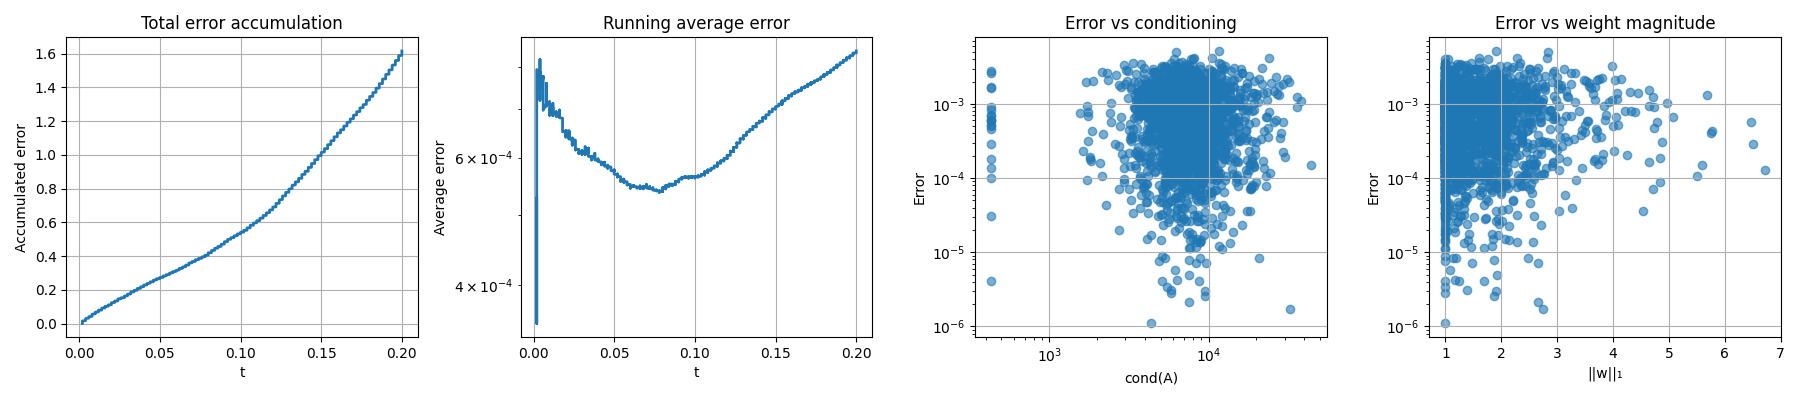

In [ ]:
from Plots.error_analysis import error_analysis

error_analysis(point_data)

### 2nd Integrator Algorithm

## 1. Initialize known points

The algorithm starts with points where the solution is known.

### Initial condition

At $t=0$:

$$
u(x,0) = \sin(\pi x)
$$

Points are sampled uniformly in $x$ and stored as

$$
(x_i,0,u_i)
$$

### Boundary conditions

Dirichlet boundaries:

$$
u(0,t)=0, \qquad u(1,t)=0
$$

These points are inserted for all time strips.

---

## 2. Generate candidate points

For each interior point $(x_i,t_i)$, new candidate points are randomly spawned:

$$
x_c = x_i + \text{Uniform}(-\Delta x, \Delta x)
$$

$$
t_c = t_i + \text{Uniform}(0,\Delta t)
$$

subject to

$$
0 \le x_c \le 1, \qquad t_c \le T
$$

These candidates represent possible new solution points.

---

## 3. Select a candidate

A random candidate $(x^*,t^*)$ is chosen.

It is rejected if it is too close to an existing point.

---

## 4. Find neighbour points

Neighbours must satisfy

$$
|x_i - x^*| \le b_x
$$

$$
0 < (t^* - t_i) \le b_t
$$

so that neighbours lie **in the past**.

If not enough neighbours are found, the search box expands.


## 5. Solve for weights

The linear system

$$
A w = b
$$

is solved with least squares.
Stencils with large condition numbers are rejected.

---

## 7. Compute the solution value

The solution at the candidate point is estimated as

$$
u(x^*,t^*) = \sum_i w_i u_i
$$

If the stencil passes quality checks, the point is **accepted** and added to the solution set.

---

## 8. Grow the solution cloud

Once a point is accepted:

* it is added to the list of known points
* new candidate points are spawned around it

The algorithm repeats until no valid candidates remain.

Notes:
- The issue is always with the geometry, if the points are too close to each other in the x direction, things go bad
- I tried to solve this issue by adding constraints on dx but we can do better


In [ ]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from matplotlib.colors import Normalize

 
# ─────────────────────────────────────────────
# Parameters
# ─────────────────────────────────────────────
alpha    = 0.05
c        = 0.5           # advection speed
T        = 0.2

nx_sc    = 100         # points per strip
# candidate generation
spawn_per_point = 2
max_candidates = 1000

n_exact  = 8        # neighbours to use
box_x0   = 0.15        # initial box half-width in x
box_t0   = 0.01        # initial box look-back in t
box_xmax = 0.1/2
box_tmax = T
box_grow = 1.5
cond_max = 1e8
candidates = []
dx_ref = 1.0 / (nx_sc - 1)
dt_sc  = 0.002         # choose directly
min_dist = 0.4 * dx_ref    # avoid duplicate points

t_strips = np.arange(0, T + dt_sc, dt_sc)

print(f"dx_ref = {dx_ref:.5f}, dt_sc = {dt_sc:.5f}, strips = {len(t_strips)-1}")

# ─────────────────────────────────────────────
# True solution and FD reference
# ─────────────────────────────────────────────
def u_true(x, t):
    # Exact solution of u_t + c*u_x = alpha*u_xx, IC sin(pi*x), Dirichlet BCs
    # via transformation u = exp(k*x - k^2*alpha*t) * v, k = c/(2*alpha)
    # v solves pure diffusion with IC exp(-k*x)*sin(pi*x)
    k = c / (2.0 * alpha)
    def f(p):
        if p == 0:
            return (1.0 - np.exp(-k)) / k if k > 1e-10 else 1.0
        return k * (1.0 - (-1)**p * np.exp(-k)) / (k**2 + (p * np.pi)**2)
    x_arr = np.asarray(x, dtype=float)
    v = np.zeros_like(x_arr)
    for n in range(1, 31):
        v += (f(n-1) - f(n+1)) * np.exp(-alpha*(n*np.pi)**2*t) * np.sin(n*np.pi*x_arr)
    result = np.exp(k*x_arr - k**2*alpha*t) * v
    return float(result) if np.ndim(x) == 0 else result

def generate_fd_reference(nx=200, dt=1e-4):
    x = np.linspace(0, 1, nx)
    dx = x[1] - x[0]

    lam = alpha * dt / dx**2   # computed internally

    if lam > 0.3:
        print(f"Warning: scheme may be unstable (λ = {lam:.3f})")

    nt = int(T / dt) + 1

    U = np.zeros((nt, nx))
    U[0] = u_true(x, 0)
    for k in range(nt-1):

        # interior (4th order diffusion + 2nd order advection)
        U[k+1,2:-2] = (
            U[k,2:-2]
            + lam/12 * (
                -U[k,4:]
                + 16*U[k,3:-1]
                - 30*U[k,2:-2]
                + 16*U[k,1:-3]
                - U[k,:-4]
            )
            - c*dt/(2*dx) * (U[k,3:-1] - U[k,1:-3])
        )

        # near boundaries (2nd order)
        U[k+1,1] = U[k,1] + lam*(U[k,2] - 2*U[k,1] + U[k,0]) - c*dt/(2*dx)*(U[k,2] - U[k,0])
        U[k+1,-2] = U[k,-2] + lam*(U[k,-1] - 2*U[k,-2] + U[k,-3]) - c*dt/(2*dx)*(U[k,-1] - U[k,-3])

        # Dirichlet BCs
        U[k+1,0] = 0
        U[k+1,-1] = 0
    return x, np.arange(nt) * dt, U

print("Generating FD reference...")
x_fd, t_fd, U_fd = generate_fd_reference()

def fd_interp(xq, tq):
    ix = np.clip(np.searchsorted(x_fd, xq) - 1, 0, len(x_fd) - 2)
    it = np.clip(np.searchsorted(t_fd, tq) - 1, 0, len(t_fd) - 2)

    tx = (xq - x_fd[ix]) / (x_fd[ix + 1] - x_fd[ix])
    tt = (tq - t_fd[it]) / (t_fd[it + 1] - t_fd[it])

    return (
        (1 - tt) * (1 - tx) * U_fd[it, ix]
        + (1 - tt) * tx * U_fd[it, ix + 1]
        + tt * (1 - tx) * U_fd[it + 1, ix]
        + tt * tx * U_fd[it + 1, ix + 1]
    )

# ─────────────────────────────────────────────
# Weight solver
# ─────────────────────────────────────────────
def solve_weights(dx_i, dt_i):
    h   = max(np.max(np.abs(dx_i)), 1e-12)
    tau = max(np.max(np.abs(dt_i)), 1e-12)

    xi = dx_i / h
    s  = dt_i / tau

    lam = alpha * tau / h**2

    A = np.array([
        np.ones(len(dx_i)),
        dx_i - c*dt_i,
        0.5*dx_i**2 + alpha*dt_i,
        (1/6)*dx_i**3 + alpha*dx_i*dt_i - alpha*c*dt_i**2
    ])
    b = np.array([1.0, 0.0, 0.0, 0.0])


    cond = np.linalg.cond(A)
    w = np.linalg.lstsq(A, b, rcond=None)[0]

    return w, cond

def far_from_existing(xc, tc, visited):

    for x, t, _ in visited:
        if abs(x - xc) < min_dist and abs(t - tc) < dt_sc * 0.5:
            return False

    return True


def spawn_candidates(xi, ti):
    new = []
    for _ in range(spawn_per_point):

        xc = xi + np.random.uniform(-box_x0, box_x0)
        tc = ti + np.random.uniform(0, box_t0)

        if 0.0 <= xc <= 1.0 and tc <= T:
            new.append((xc, tc))

    return new  

# ─────────────────────────────────────────────
# Neighbour search
# ─────────────────────────────────────────────
def find_neighbours(x_star, t_star, visited):
    bx, bt = box_x0, box_t0

    while True:
        nb = [
            p for p in visited
            if abs(p[0] - x_star) <= bx
            and 0 < (t_star - p[1]) <= bt
        ]

        if len(nb) >= n_exact:
            nb.sort(key=lambda p: (p[0] - x_star)**2 + (p[1] - t_star)**2)
            return nb[:n_exact]

        bx = min(bx * box_grow, box_xmax)
        bt = min(bt * box_grow, box_tmax)

        if bx >= box_xmax and bt >= box_tmax:
            return None

# ─────────────────────────────────────────────
# Run integrator
# ─────────────────────────────────────────────
visited = []
point_data = []

# Initial condition
x_ic = np.linspace(0, 1, nx_sc)
for xi in x_ic:
    visited.append((xi, 0.0, u_true(xi, 0.0)))

# Boundary points (Dirichlet BCs)
t_bc = np.arange(0, T + dt_sc, dt_sc)

for t in t_bc:
    visited.append((0.0, t, 0.0))  # left boundary
    visited.append((1.0, t, 0.0))  # right boundary
t_bc = np.arange(0, T + dt_sc, dt_sc)

for xi, ti, ui in visited:
    # skip boundary points
    if abs(xi) < 1e-12 or abs(xi - 1) < 1e-12:
        continue

    candidates.extend(spawn_candidates(xi, ti))
while candidates:

    # keep list bounded
    if len(candidates) > max_candidates:
        candidates = candidates[-max_candidates:]

    # pick random candidate
    idx = np.random.randint(len(candidates))
    x_star, t_star = candidates.pop(idx)

  
    # skip if too close to existing points
    if not far_from_existing(x_star, t_star, visited):
        continue

    # skip if too close to existing points
    if not far_from_existing(x_star, t_star, visited):
        continue

    # add boundary conditions
    if abs(x_star) < 1e-12 or abs(x_star-1) < 1e-12:
        visited.append((x_star, t_star, 0.0))
        continue

    nb = find_neighbours(x_star, t_star, visited)
    if nb is None:
        continue

    nb_pts = np.array(nb)
    dx_i = nb_pts[:, 0] - x_star
    dt_i = nb_pts[:, 1] - t_star
    u_i = nb_pts[:, 2]

    # one-sided stencil
    if np.min(dx_i) * np.max(dx_i) > 0:
        continue

    # too thin stencil
    span = np.max(dx_i) - np.min(dx_i)
    if span < 0.9 * dx_ref:

        continue
        

    w, cond = solve_weights(dx_i, dt_i)
    if cond > cond_max:
        continue
    u_hat = w @ u_i
    visited.append((x_star, t_star, u_hat))

    # spawn new candidates around accepted point
    candidates.extend(spawn_candidates(x_star, t_star))

    # store data for diagnostics
    u_ref = fd_interp(x_star, t_star)

    point_data.append({
        'x': x_star,
        't': t_star,
        'u': u_hat,
        'err': abs(u_hat - u_ref),
        'w1': np.sum(np.abs(w)),
        'cond': cond,
        'nb_x': nb_pts[:, 0].copy(),
        'nb_t': nb_pts[:, 1].copy(),
        'nb_u': nb_pts[:, 2].copy(),
        'box_x': np.max(np.abs(dx_i)),
        'box_t': np.max(np.abs(dt_i)),
    })
    if len(candidates) > max_candidates:
        candidates = candidates[-max_candidates:]
print(
    f"Done. {len(point_data)} points,  "
    f"mean err = {np.mean([p['err'] for p in point_data]):.3e},  "
    f"max err = {np.max([p['err'] for p in point_data]):.3e}"
)

px   = np.array([p['x'] for p in point_data])
pt   = np.array([p['t'] for p in point_data])
pu   = np.array([p['u'] for p in point_data])
perr = np.array([p['err'] for p in point_data])
tol_bc = 1e-12

bc_x = np.array([p[0] for p in visited if abs(p[0]) < tol_bc or abs(p[0]-1) < tol_bc])
bc_t = np.array([p[1] for p in visited if abs(p[0]) < tol_bc or abs(p[0]-1) < tol_bc])
ic_x = x_ic
ic_t = np.zeros(len(ic_x))

# diagnostic arrays
cond_vals = np.array([p['cond'] for p in point_data])
w1_vals   = np.array([p['w1'] for p in point_data])

true_vals = np.array([u_true(p['x'], p['t']) for p in point_data])


dx_ref = 0.01010, dt_sc = 0.00200, strips = 100
Generating FD reference...
Done. 8428 points,  mean err = 1.968e-03,  max err = 2.987e-02


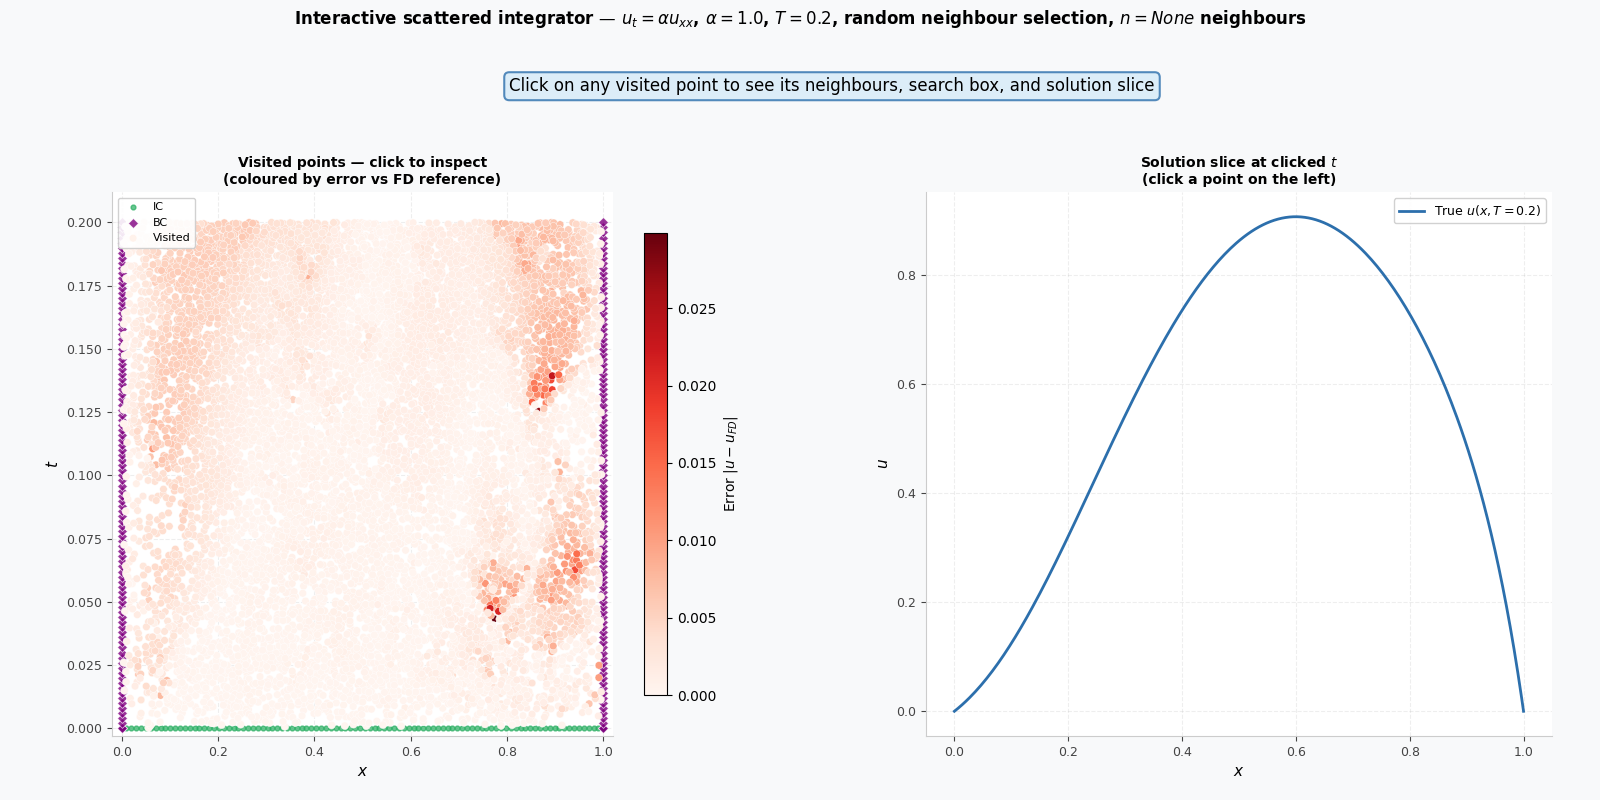

In [ ]:
#------------------------------------------------------------------------
from Plots.interactive_plot import interactive_plot
bc_x = np.array([p[0] for p in visited if p[0] in [0.0,1.0]])
bc_t = np.array([p[1] for p in visited if p[0] in [0.0,1.0]])
interactive_plot(
    point_data,
    visited,
    u_true,
    fd_interp,
    T,
    dt_sc,
    ic_x,
    ic_t,
    bc_x,
    bc_t
)

add advection at least, then check KS 


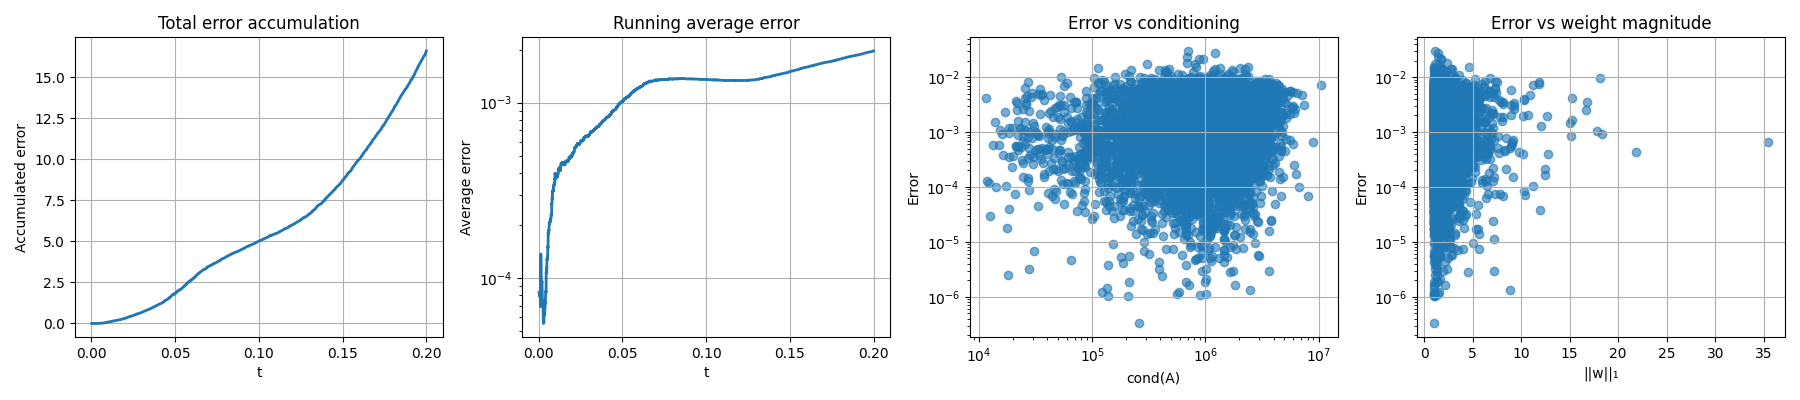

In [ ]:
from Plots.error_analysis import error_analysis

error_analysis(point_data)

## do it for multiple passes to see what is the prediction for different neighbours. and then find what is the error and the varience for different neighbours. uncertaintity 

### NOTES FROM CLAUDE ON THE EIGEN VALUE OF DX AND DTs, TO BE REVIEWED MORE

In [14]:
import numpy as np

# ─────────────────────────────────────────────
# Parameters
# ─────────────────────────────────────────────
alpha    = 0.05
c        = 0.5
T        = 1

nx_sc    = 100
spawn_per_point = 2
max_candidates  = 1000

n_exact  = 5
box_x0   = 0.15
box_t0   = 0.01
box_xmax = 0.1 / 2
box_tmax = T
box_grow = 1.5

cond_max     = 1e4       # was 1e8 — now meaningful after normalization fix
isotropy_max = 25.0      # max λ_max/λ_min for the neighbor point cloud

dx_ref   = 1.0 / (nx_sc - 1)
dt_sc    = 0.002
min_dist = 0.4 * dx_ref

t_strips = np.arange(0, T + dt_sc, dt_sc)
print(f"dx_ref = {dx_ref:.5f}, dt_sc = {dt_sc:.5f}, strips = {len(t_strips)-1}")


# ─────────────────────────────────────────────
# True solution
# ─────────────────────────────────────────────
def u_true(x, t):
    k = c / (2.0 * alpha)
    def f(p):
        if p == 0:
            return (1.0 - np.exp(-k)) / k if k > 1e-10 else 1.0
        return k * (1.0 - (-1)**p * np.exp(-k)) / (k**2 + (p * np.pi)**2)
    x_arr = np.asarray(x, dtype=float)
    v = np.zeros_like(x_arr)
    for n in range(1, 31):
        v += (f(n-1) - f(n+1)) * np.exp(-alpha*(n*np.pi)**2*t) * np.sin(n*np.pi*x_arr)
    result = np.exp(k*x_arr - k**2*alpha*t) * v
    return float(result) if np.ndim(x) == 0 else result


# ─────────────────────────────────────────────
# FD reference
# ─────────────────────────────────────────────
def generate_fd_reference(nx=200, dt=1e-4):
    x   = np.linspace(0, 1, nx)
    dx  = x[1] - x[0]
    lam = alpha * dt / dx**2

    if lam > 0.3:
        print(f"Warning: scheme may be unstable (λ = {lam:.3f})")

    nt = int(T / dt) + 1
    U  = np.zeros((nt, nx))
    U[0] = u_true(x, 0)

    for k in range(nt - 1):
        U[k+1, 2:-2] = (
            U[k, 2:-2]
            + lam / 12 * (
                -U[k, 4:]
                + 16*U[k, 3:-1]
                - 30*U[k, 2:-2]
                + 16*U[k, 1:-3]
                - U[k, :-4]
            )
            - c*dt / (2*dx) * (U[k, 3:-1] - U[k, 1:-3])
        )
        U[k+1, 1]  = U[k, 1]  + lam*(U[k, 2]  - 2*U[k, 1]  + U[k, 0])  - c*dt/(2*dx)*(U[k, 2]  - U[k, 0])
        U[k+1, -2] = U[k, -2] + lam*(U[k, -1] - 2*U[k, -2] + U[k, -3]) - c*dt/(2*dx)*(U[k, -1] - U[k, -3])
        U[k+1, 0]  = 0.0
        U[k+1, -1] = 0.0

    return x, np.arange(nt) * dt, U


print("Generating FD reference...")
x_fd, t_fd, U_fd = generate_fd_reference()


def fd_interp(xq, tq):
    ix = np.clip(np.searchsorted(x_fd, xq) - 1, 0, len(x_fd) - 2)
    it = np.clip(np.searchsorted(t_fd, tq) - 1, 0, len(t_fd) - 2)
    tx = (xq - x_fd[ix]) / (x_fd[ix+1] - x_fd[ix])
    tt = (tq - t_fd[it]) / (t_fd[it+1] - t_fd[it])
    return (
        (1-tt)*(1-tx)*U_fd[it,   ix]
      + (1-tt)*tx    *U_fd[it,   ix+1]
      +    tt *(1-tx)*U_fd[it+1, ix]
      +    tt *tx    *U_fd[it+1, ix+1]
    )


# ─────────────────────────────────────────────
# Stencil quality — geometry check (before solve)
# ─────────────────────────────────────────────
def stencil_is_good(dx_i, dt_i):
    # 1. Two-sided spatial coverage
    if np.min(dx_i) * np.max(dx_i) > 0:
        return False

    # 2. Minimum spatial span
    if np.max(dx_i) - np.min(dx_i) < 0.9 * dx_ref:
        return False

    # 3. Eigenvalue ratio of point cloud — catches collinearity in (x,t) space
    #    Normalize first so x and t contribute on equal footing
    h   = max(np.max(np.abs(dx_i)), 1e-12)
    tau = max(np.max(np.abs(dt_i)), 1e-12)

    pts  = np.column_stack([dx_i / h, dt_i / tau])   # (n, 2)
    C    = pts.T @ pts                                 # 2×2 scatter matrix
    eigs = np.linalg.eigvalsh(C)                       # sorted ascending

    if eigs[0] < 1e-14:                                # numerically flat cloud
        return False
    if eigs[1] / eigs[0] > isotropy_max:               # too elongated / collinear
        return False

    return True


# ─────────────────────────────────────────────
# Weight solver — normalized A + pseudoinverse (SVD)
# ─────────────────────────────────────────────
def solve_weights(dx_i, dt_i):
    h   = max(np.max(np.abs(dx_i)), 1e-12)
    tau = max(np.max(np.abs(dt_i)), 1e-12)

    # Rows normalized to O(1) — fixes the artificial condition number inflation
    A = np.array([
        np.ones(len(dx_i)),
        (dx_i - c*dt_i)                                        / h,
        (0.5*dx_i**2 + alpha*dt_i)                             / h**2
    ])  # shape (4, n)
    b = np.array([1.0, 0.0, 0.0])

    # cond(A) now reflects geometry, not units
    cond = np.linalg.cond(A)
    if cond > cond_max:
        return None, cond

    # Pseudoinverse via SVD — minimum Euclidean norm solution
    w = np.linalg.lstsq(A, b, rcond=None)[0]
    return w, cond


# ─────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────
def far_from_existing(xc, tc, visited):
    for x, t, _ in visited:
        if abs(x - xc) < min_dist and abs(t - tc) < dt_sc * 0.5:
            return False
    return True


def spawn_candidates(xi, ti):
    new = []
    for _ in range(spawn_per_point):
        xc = xi + np.random.uniform(-box_x0, box_x0)
        tc = ti + np.random.uniform(0, box_t0)
        if 0.0 <= xc <= 1.0 and tc <= T:
            new.append((xc, tc))
    return new


def find_neighbours(x_star, t_star, visited):
    bx, bt = box_x0, box_t0
    while True:
        nb = [
            p for p in visited
            if abs(p[0] - x_star) <= bx
            and 0 < (t_star - p[1]) <= bt
        ]
        if len(nb) >= n_exact:
            nb.sort(key=lambda p: (p[0] - x_star)**2 + (p[1] - t_star)**2)
            return nb[:n_exact]
        bx = min(bx * box_grow, box_xmax)
        bt = min(bt * box_grow, box_tmax)
        if bx >= box_xmax and bt >= box_tmax:
            return None


# ─────────────────────────────────────────────
# Main integrator — wrapped for UQ
# ─────────────────────────────────────────────
def run_integrator(seed=None):
    if seed is not None:
        np.random.seed(seed)

    visited    = []
    point_data = []

    # Initial condition
    for xi in np.linspace(0, 1, nx_sc):
        visited.append((xi, 0.0, u_true(xi, 0.0)))

    # Boundary conditions
    for t in np.arange(0, T + dt_sc, dt_sc):
        visited.append((0.0, t, 0.0))
        visited.append((1.0, t, 0.0))

    # Seed candidates from IC interior points only
    candidates = []
    for xi, ti, _ in visited:
        if abs(xi) < 1e-12 or abs(xi - 1.0) < 1e-12:
            continue
        candidates.extend(spawn_candidates(xi, ti))

    while candidates:
        if len(candidates) > max_candidates:
            candidates = candidates[-max_candidates:]

        idx = np.random.randint(len(candidates))
        x_star, t_star = candidates.pop(idx)

        # Single proximity check (was duplicated in original)
        if not far_from_existing(x_star, t_star, visited):
            continue

        # Boundary points
        if abs(x_star) < 1e-12 or abs(x_star - 1.0) < 1e-12:
            visited.append((x_star, t_star, 0.0))
            continue

        nb = find_neighbours(x_star, t_star, visited)
        if nb is None:
            continue

        nb_pts = np.array(nb)
        dx_i   = nb_pts[:, 0] - x_star
        dt_i   = nb_pts[:, 1] - t_star

        # Geometry check — eigenvalue ratio + span + two-sided
        if not stencil_is_good(dx_i, dt_i):
            continue

        # Solve — normalized A, cond(A) check, pseudoinverse
        w, cond = solve_weights(dx_i, dt_i)
        if w is None:
            continue

        u_hat = w @ nb_pts[:, 2]
        visited.append((x_star, t_star, u_hat))
        candidates.extend(spawn_candidates(x_star, t_star))

        u_ref = fd_interp(x_star, t_star)
        point_data.append({
            'x':     x_star,
            't':     t_star,
            'u':     u_hat,
            'err':   abs(u_hat - u_ref),
            'w1':    np.sum(np.abs(w)),
            'cond':  cond,
            'nb_x':  nb_pts[:, 0].copy(),
            'nb_t':  nb_pts[:, 1].copy(),
            'nb_u':  nb_pts[:, 2].copy(),
            'box_x': np.max(np.abs(dx_i)),
            'box_t': np.max(np.abs(dt_i)),
        })

    return visited, point_data


# ─────────────────────────────────────────────
# Diagnostics helper
# ─────────────────────────────────────────────
def summarise(point_data, visited):
    print(
        f"Done. {len(point_data)} points,  "
        f"mean err = {np.mean([p['err'] for p in point_data]):.3e},  "
        f"max err  = {np.max([p['err'] for p in point_data]):.3e}"
    )

    px        = np.array([p['x']    for p in point_data])
    pt        = np.array([p['t']    for p in point_data])
    pu        = np.array([p['u']    for p in point_data])
    perr      = np.array([p['err']  for p in point_data])
    cond_vals = np.array([p['cond'] for p in point_data])
    w1_vals   = np.array([p['w1']   for p in point_data])
    true_vals = np.array([u_true(p['x'], p['t']) for p in point_data])

    tol_bc = 1e-12
    bc_x = np.array([p[0] for p in visited if abs(p[0]) < tol_bc or abs(p[0]-1) < tol_bc])
    bc_t = np.array([p[1] for p in visited if abs(p[0]) < tol_bc or abs(p[0]-1) < tol_bc])
    ic_x = np.linspace(0, 1, nx_sc)
    ic_t = np.zeros(len(ic_x))

    return dict(
        px=px, pt=pt, pu=pu, perr=perr,
        cond_vals=cond_vals, w1_vals=w1_vals,
        true_vals=true_vals,
        bc_x=bc_x, bc_t=bc_t,
        ic_x=ic_x, ic_t=ic_t,
    )

if __name__ == "__main__":
    visited, point_data = run_integrator(seed=0)
    if point_data:
        errs = [p['err'] for p in point_data]
        print(f"n_points={len(point_data):4d}, "
              f"mean_err={np.mean(errs):.2e}, max_err={np.max(errs):.2e}")
    # Expose for diagnostics
    ic_x = np.linspace(0, 1, nx_sc)
    ic_t = np.zeros(len(ic_x))
    diag = summarise(point_data, visited)

dx_ref = 0.01010, dt_sc = 0.00200, strips = 500
Generating FD reference...
n_points=35524, mean_err=1.99e-02, max_err=6.23e-01
Done. 35524 points,  mean err = 1.994e-02,  max err  = 6.225e-01


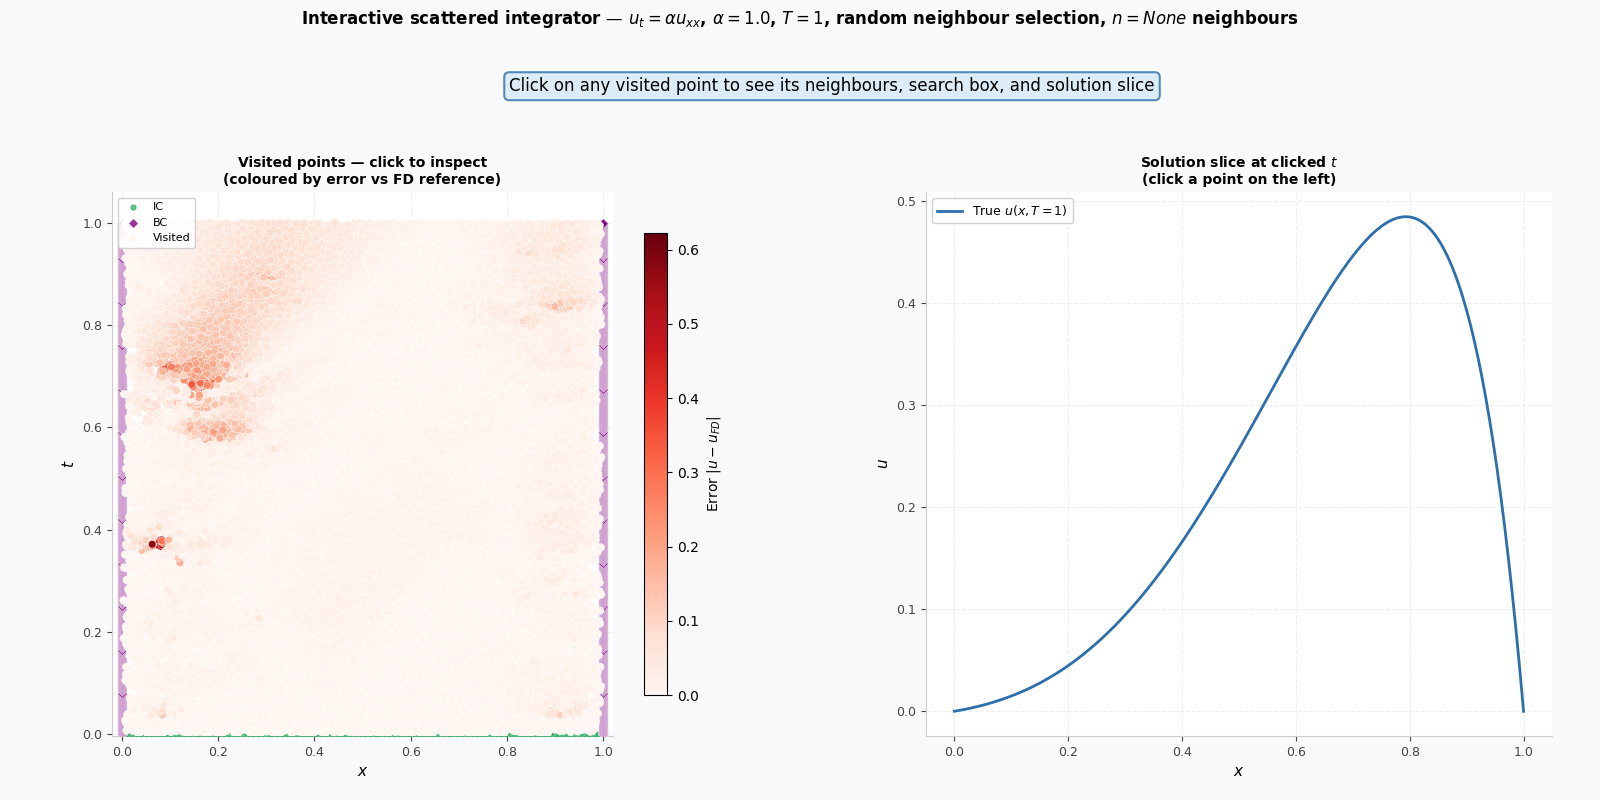

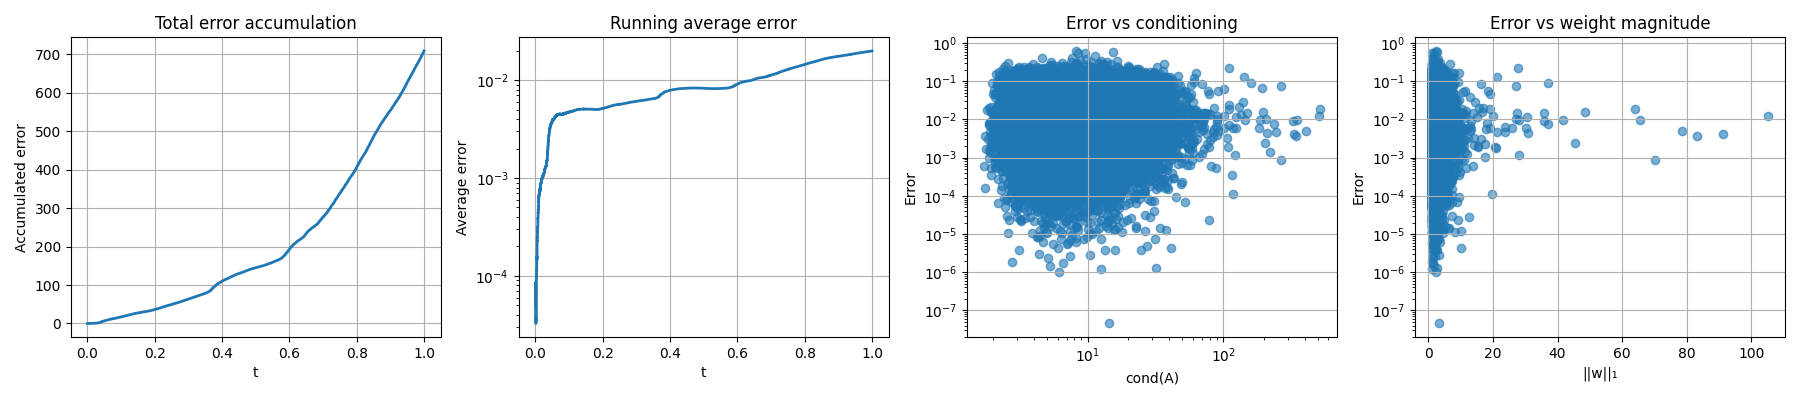

In [16]:
#------------------------------------------------------------------------
%matplotlib widget
from Plots.interactive_plot import interactive_plot
bc_x = np.array([p[0] for p in visited if p[0] in [0.0,1.0]])
bc_t = np.array([p[1] for p in visited if p[0] in [0.0,1.0]])
interactive_plot(
    point_data,
    visited,
    u_true,
    fd_interp,
    T,
    dt_sc,
    ic_x,
    ic_t,
    bc_x,
    bc_t
)
from Plots.error_analysis import error_analysis

error_analysis(point_data)